###Mount Google Drive

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Import necessary libraries

In [12]:
import os
import numpy as np
import nibabel as nib
import cv2
import glob

In [ ]:
# ================= CONFIGURATION =================
# Path to the BraTS dataset folder
# Structure: ./BraTS-Africa/95_Glioma/[SubjectID]/[files]

DATA_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/BraTS-Africa/95_Glioma'
OUTPUT_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'

# How many patients to process
NUM_PATIENTS = 95

# Slices to extract per patient
SLICES_PER_PATIENT = 5

# Image settings
IMG_SIZE = (224, 224)
# =================================================

In [ ]:
def normalize_slice(slice_data):
    """
    Normalizes MRI intensity to 0-255 (uint8) with outlier clipping.
    """
    p99 = np.percentile(slice_data, 99)
    slice_data = np.clip(slice_data, 0, p99)

    img_min = slice_data.min()
    img_max = slice_data.max()

    if img_max - img_min == 0:
        return slice_data.astype(np.uint8)

    normalized = (slice_data - img_min) / (img_max - img_min)
    return (normalized * 255).astype(np.uint8)

def process_gliomas():
    os.makedirs(OUTPUT_ROOT, exist_ok=True)

    # 1. Get Patient List
    patient_dirs = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])

    selected_patients = patient_dirs[:NUM_PATIENTS]
    print(f"Selecting first {len(selected_patients)} patients from {len(patient_dirs)} total.")

    total_images = 0

    for pat_id in selected_patients:
        pat_path = os.path.join(DATA_ROOT, pat_id)

        # --- THE FIX IS HERE ---
        # We construct the filename using the patient ID folder name
        t1c_filename = f"{pat_id}-t1c.nii.gz"
        seg_filename = f"{pat_id}-seg.nii.gz"

        t1c_path = os.path.join(pat_path, t1c_filename)
        seg_path = os.path.join(pat_path, seg_filename)

        if not os.path.exists(t1c_path) or not os.path.exists(seg_path):
            print(f"Skipping {pat_id}: Files missing.\n  Expected: {t1c_path}")
            continue

        try:
            # 3. Load 3D Volumes
            t1c_vol = nib.load(t1c_path).get_fdata()
            seg_vol = nib.load(seg_path).get_fdata()
        except Exception as e:
            print(f"Error loading {pat_id}: {e}")
            continue

        # 4. Find the 'Best' Slices (largest tumor area)
        slice_scores = []
        depth = seg_vol.shape[2]

        for z in range(depth):
            tumor_area = np.sum(seg_vol[:, :, z] > 0)
            if tumor_area > 0:
                slice_scores.append((z, tumor_area))

        slice_scores.sort(key=lambda x: x[1], reverse=True)
        top_slices = slice_scores[:SLICES_PER_PATIENT]

        if not top_slices:
            print(f"No tumor mask found for {pat_id}")
            continue

        # 5. Extract, Resize, and Save
        for (z_index, area) in top_slices:
            img_slice = t1c_vol[:, :, z_index]

            # Rotate if needed (MRI scans often load sideways)
            img_slice = np.rot90(img_slice, k=1)

            img_norm = normalize_slice(img_slice)
            img_resized = cv2.resize(img_norm, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

            filename = f"{pat_id}_slice{z_index}.png"
            cv2.imwrite(os.path.join(OUTPUT_ROOT, filename), img_resized)
            total_images += 1

        print(f"Processed {pat_id}: Saved {len(top_slices)} slices.")

    print(f"Done! Extracted {total_images} images to {OUTPUT_ROOT}")

if __name__ == "__main__":
    process_gliomas()

Selecting first 95 patients from 95 total.
Processed BraTS-SSA-00002-000: Saved 5 slices.
Processed BraTS-SSA-00007-000: Saved 5 slices.
Processed BraTS-SSA-00008-000: Saved 5 slices.
Processed BraTS-SSA-00010-000: Saved 5 slices.
Processed BraTS-SSA-00011-000: Saved 5 slices.
Processed BraTS-SSA-00012-000: Saved 5 slices.
Processed BraTS-SSA-00014-000: Saved 5 slices.
Processed BraTS-SSA-00015-000: Saved 5 slices.
Processed BraTS-SSA-00025-000: Saved 5 slices.
Processed BraTS-SSA-00026-000: Saved 5 slices.
Processed BraTS-SSA-00028-000: Saved 5 slices.
Processed BraTS-SSA-00037-000: Saved 5 slices.
Processed BraTS-SSA-00041-000: Saved 5 slices.
Processed BraTS-SSA-00044-000: Saved 5 slices.
Processed BraTS-SSA-00046-000: Saved 5 slices.
Processed BraTS-SSA-00047-000: Saved 5 slices.
Processed BraTS-SSA-00049-000: Saved 5 slices.
Processed BraTS-SSA-00050-000: Saved 5 slices.
Processed BraTS-SSA-00051-000: Saved 5 slices.
Processed BraTS-SSA-00055-000: Saved 5 slices.
Processed BraTS-S

In [ ]:
!pip install nibabel
import os
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
# 1. Input: Where your raw BraTS 3D files are (Change if different)
# Assuming typical BraTS structure: parent_folder/Patient_ID/files...
DATA_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/BraTS-Africa/95_Glioma'

# 2. Output: The NEW folder for T2 images
OUTPUT_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

# 3. Settings
NUM_PATIENTS = 95
SLICES_PER_PATIENT = 5
IMG_SIZE = (224, 224)
# =================================================

def normalize_slice(slice_data):
    """
    Normalizes MRI intensity to 0-255 (uint8) with outlier clipping.
    This helps the tumor stand out against the background.
    """
    # Clip top 1% outliers (often scanner noise)
    p99 = np.percentile(slice_data, 99)
    slice_data = np.clip(slice_data, 0, p99)

    img_min = slice_data.min()
    img_max = slice_data.max()

    if img_max - img_min == 0:
        return slice_data.astype(np.uint8)

    # Min-Max Scaling to 0-255
    normalized = (slice_data - img_min) / (img_max - img_min)
    return (normalized * 255).astype(np.uint8)

def process_gliomas_t2():
    # Create the new output directory
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    print(f"📂 Created/Found output directory: {OUTPUT_ROOT}")

    # Get Patient List
    if not os.path.exists(DATA_ROOT):
        print(f"❌ Error: Data root not found at {DATA_ROOT}")
        return

    patient_dirs = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])

    # Select subset
    if NUM_PATIENTS:
        selected_patients = patient_dirs[:NUM_PATIENTS]
    else:
        selected_patients = patient_dirs

    print(f"🚀 Processing {len(selected_patients)} patients looking for T2-weighted scans...")

    total_images = 0

    for pat_id in selected_patients:
        pat_path = os.path.join(DATA_ROOT, pat_id)

        # --- THE FIX: Smart Modality Search ---
        # We look for T2 first, then T2-FLAIR.
        # This matches the "bright tumor" look of your training data.
        possible_t2_files = [
            f"{pat_id}-t2w.nii.gz",  # Standard T2
            f"{pat_id}-t2.nii.gz",   # Alternative T2
            f"{pat_id}-t2f.nii.gz",  # T2-FLAIR (also very good)
            f"{pat_id}-fla.nii.gz"   # FLAIR alternative
        ]

        t2_path = None
        found_modality = ""

        for fname in possible_t2_files:
            check_path = os.path.join(pat_path, fname)
            if os.path.exists(check_path):
                t2_path = check_path
                found_modality = fname
                break

        # Always need the segmentation mask to find the tumor
        seg_filename = f"{pat_id}-seg.nii.gz"
        seg_path = os.path.join(pat_path, seg_filename)

        if t2_path is None or not os.path.exists(seg_path):
            print(f"⚠️ Skipping {pat_id}: T2 or Seg file missing.")
            continue

        try:
            # Load 3D Volumes
            t2_vol = nib.load(t2_path).get_fdata()
            seg_vol = nib.load(seg_path).get_fdata()
        except Exception as e:
            print(f"❌ Error loading {pat_id}: {e}")
            continue

        # Find the 'Best' Slices (largest tumor area)
        slice_scores = []
        depth = seg_vol.shape[2]

        for z in range(depth):
            # We look for the mask (labels 1, 2, or 4 usually)
            tumor_area = np.sum(seg_vol[:, :, z] > 0)
            if tumor_area > 0:
                slice_scores.append((z, tumor_area))

        # Sort by tumor size (biggest first)
        slice_scores.sort(key=lambda x: x[1], reverse=True)
        top_slices = slice_scores[:SLICES_PER_PATIENT]

        if not top_slices:
            print(f"⚠️ No tumor mask found in segmentation for {pat_id}")
            continue

        # Extract, Resize, and Save
        for (z_index, area) in top_slices:
            img_slice = t2_vol[:, :, z_index]

            # Rotate if needed (MRI scans often load sideways in NIfTI)
            img_slice = np.rot90(img_slice, k=1)

            # Normalize specifically for T2 contrast
            img_norm = normalize_slice(img_slice)

            # Resize to model input size
            img_resized = cv2.resize(img_norm, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

            # Save to the NEW T2 folder
            filename = f"{pat_id}_slice{z_index}_t2.png"
            cv2.imwrite(os.path.join(OUTPUT_ROOT, filename), img_resized)
            total_images += 1

        print(f"✅ Processed {pat_id} ({found_modality}): Saved {len(top_slices)} slices.")

    print(f"\n🎉 DONE! Extracted {total_images} T2 images to:\n{OUTPUT_ROOT}")

if __name__ == "__main__":
    process_gliomas_t2()

📂 Created/Found output directory: /content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2
🚀 Processing 95 patients looking for T2-weighted scans...
✅ Processed BraTS-SSA-00002-000 (BraTS-SSA-00002-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00007-000 (BraTS-SSA-00007-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00008-000 (BraTS-SSA-00008-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00010-000 (BraTS-SSA-00010-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00011-000 (BraTS-SSA-00011-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00012-000 (BraTS-SSA-00012-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00014-000 (BraTS-SSA-00014-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00015-000 (BraTS-SSA-00015-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00025-000 (BraTS-SSA-00025-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00026-000 (BraTS-SSA-00026-000-t2w.nii.gz): Saved 5 slices.
✅ P

In [ ]:
import os

folder_path = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

if os.path.exists(folder_path):
    file_count = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
    print(f"✅ Found {file_count} images in '{folder_path}'")

    if file_count == 475:
        print("🎉 Perfect! You have exactly 95 patients × 5 slices.")
    else:
        print(f"⚠️ Warning: Expected 475 images, but found {file_count}.")
else:
    print(f"❌ Error: The folder '{folder_path}' does not exist.")

✅ Found 475 images in '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'
🎉 Perfect! You have exactly 95 patients × 5 slices.


In [ ]:
import os

folder_path = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

files = os.listdir(folder_path)
t2_files = [f for f in files if f.endswith('_t2.png')]
t1c_files = [f for f in files if f.endswith('.png') and not f.endswith('_t2.png')]

print(f"Total T2 images: {len(t2_files)}")
print(f"Total T1c images: {len(t1c_files)}")

Total T2 images: 475
Total T1c images: 475


In [ ]:
import os
import shutil

src_dir = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'
dst_dir = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'

os.makedirs(dst_dir, exist_ok=True)

moved_count = 0
for f in os.listdir(src_dir):
    # Move T1c files (files that don't end in _t2.png)
    if f.endswith('.png') and not f.endswith('_t2.png'):
        shutil.move(os.path.join(src_dir, f), os.path.join(dst_dir, f))
        moved_count += 1

print(f"✅ Moved {moved_count} T1c slices to '{dst_dir}'")
print(f"Remaining T2 images in 'glioma_t2': {len(os.listdir(src_dir))}")

✅ Moved 475 T1c slices to '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'
Remaining T2 images in 'glioma_t2': 475


In [19]:
import os
import glob
import shutil
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# ================= 1. CLEAN MOUNT & DEVICE SETUP =================
os.system('umount -f /content/drive 2>/dev/null')
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
print("🔄 Mounting Google Drive...")
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ================= 2. CONFIGURATION & OPTIMIZATIONS =================
SEEDS = [12, 23, 42, 2026]
SPLIT_RATIO = 0.40  # 40% patient-level validation holdout
NUM_EPOCHS = 25     # Maximum training epochs per seed
BATCH_SIZE = 32     # Maximize GPU throughput
NUM_WORKERS = 2     # Parallel asynchronous loading
USE_AMP = device.type == 'cuda'  # Automatic Mixed Precision

# ================= 3. PATH RESOLUTION & LOCAL SSD CACHING =================
path_mydrive = '/content/drive/MyDrive/Computer Vision Project/datasets'
path_my_drive = '/content/drive/My Drive/Computer Vision Project/datasets'

if os.path.exists(path_mydrive):
    DRIVE_BASE = path_mydrive
elif os.path.exists(path_my_drive):
    DRIVE_BASE = path_my_drive
else:
    raise FileNotFoundError("❌ Could not locate 'Computer Vision Project/datasets' directory in Drive.")

LOCAL_BASE = '/tmp/datasets'

if not os.path.exists(LOCAL_BASE):
    print(f"⚡ Copying dataset from Google Drive to fast local SSD ({LOCAL_BASE})...")
    t0 = time.time()
    shutil.copytree(DRIVE_BASE, LOCAL_BASE)
    print(f"✅ Dataset cached locally in {time.time() - t0:.1f} seconds!")
else:
    print("✅ Fast local dataset copy verified.")

BASE_DIR = LOCAL_BASE

TUMOR_DIR = os.path.join(BASE_DIR, 'braTS_africa_test', 'glioma')
if not os.path.exists(TUMOR_DIR):
    TUMOR_DIR = os.path.join(BASE_DIR, 'braTS_africa_test')

WESTERN_DIR = os.path.join(BASE_DIR, 'tumor')
HEALTHY_DIR = os.path.join(BASE_DIR, 'axial')

SAVE_WEIGHTS_DIR = os.path.join(os.path.dirname(DRIVE_BASE), 'checkpoints')
os.makedirs(SAVE_WEIGHTS_DIR, exist_ok=True)

print(f"\n✅ Working Base Directory : {BASE_DIR}")
print(f"African Tumor Directory  : {TUMOR_DIR} (Exists: {os.path.exists(TUMOR_DIR)})")
print(f"Western Tumor Directory  : {WESTERN_DIR} (Exists: {os.path.exists(WESTERN_DIR)})")
print(f"Healthy Controls Dir     : {HEALTHY_DIR} (Exists: {os.path.exists(HEALTHY_DIR)})\n")

# ================= 4. DATASET & TRANSFORMS =================
class MRIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_patient_id(filename):
    base = os.path.basename(filename)
    if '_slice' in base:
        return base.split('_slice')[0]
    return base.split('.')[0]

def load_all_datasets():
    filepaths, labels, groups = [], [], []
    valid_exts = ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.PNG', '*.JPG', '*.JPEG', '*.TIF')

    def scan_directory(directory_path, label):
        if not os.path.exists(directory_path):
            print(f"⚠️ Warning: Path does not exist: {directory_path}")
            return 0

        found = 0
        for ext in valid_exts:
            for f in glob.glob(os.path.join(directory_path, '**', ext), recursive=True):
                filepaths.append(f)
                labels.append(label)
                groups.append(extract_patient_id(f))
                found += 1
        print(f"Loaded {found:4d} images from: {directory_path}")
        return found

    print("--- Loading Image Collections ---")
    scan_directory(TUMOR_DIR, label=1)
    scan_directory(WESTERN_DIR, label=1)
    scan_directory(HEALTHY_DIR, label=0)
    print("---------------------------------\n")

    return pd.DataFrame({'filepath': filepaths, 'label': labels, 'patient_id': groups})

# ================= 5. AMP-SAFE LOSS & ARCHITECTURE =================
class FocalLossWithLogits(nn.Module):
    """Numerically stable Focal Loss using binary_cross_entropy_with_logits for AMP autocast."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

class DINOv2Classifier(nn.Module):
    def __init__(self, backbone_model):
        super().__init__()
        self.backbone = backbone_model

        for param in self.backbone.parameters():
            param.requires_grad = False

        for param in self.backbone.blocks[-2:].parameters():
            param.requires_grad = True

        # Removed output Sigmoid; outputs raw logits directly for AMP stability
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features).squeeze(-1)

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return sensitivity, specificity

# ================= 6. FAST MULTI-SEED TRAINING & EVALUATION =================
df = load_all_datasets()
print(f"Total Images Loaded: {len(df)} (Tumors: {sum(df['label']==1)}, Healthy: {sum(df['label']==0)})")

if len(df) == 0:
    raise ValueError("❌ No image files were loaded! Verify local directory paths.")

results = []
total_start_time = time.time()

for seed in SEEDS:
    print(f"\n--- Starting Training Pipeline for Seed {seed} ---")
    seed_start_time = time.time()

    brats_df = df[df['label'] == 1].copy()
    healthy_df = df[df['label'] == 0].copy()

    gss_tumor = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    train_t_idx, val_t_idx = next(gss_tumor.split(brats_df, brats_df['label'], groups=brats_df['patient_id']))
    brats_train, brats_val = brats_df.iloc[train_t_idx], brats_df.iloc[val_t_idx]

    gss_healthy = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    train_h_idx, val_h_idx = next(gss_healthy.split(healthy_df, healthy_df['label'], groups=healthy_df['patient_id']))
    healthy_train, healthy_val = healthy_df.iloc[train_h_idx], healthy_df.iloc[val_h_idx]

    train_df = pd.concat([brats_train, healthy_train]).sample(frac=1, random_state=seed).reset_index(drop=True)

    train_dataset = MRIDataset(train_df['filepath'].values, train_df['label'].values, transform=train_transforms)
    val_brats_dataset = MRIDataset(brats_val['filepath'].values, brats_val['label'].values, transform=val_transforms)
    val_healthy_dataset = MRIDataset(healthy_val['filepath'].values, healthy_val['label'].values, transform=val_transforms)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
    )
    val_brats_loader = DataLoader(
        val_brats_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
    )
    val_healthy_loader = DataLoader(
        val_healthy_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
    )

    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)

    criterion = FocalLossWithLogits(alpha=0.25, gamma=2.0)

    optimizer = optim.AdamW([
        {'params': model.backbone.blocks[-2:].parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-2)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7)

    # Modern PyTorch AMP API setup
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    # Accelerated Training Loop
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataset)
        scheduler.step(epoch_loss)

    # Save Checkpoint back to persistent Google Drive
    checkpoint_path = os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth")
    torch.save(model.state_dict(), checkpoint_path)

    # Fast Evaluation (Logit >= 0.0 is equivalent to Sigmoid >= 0.5)
    model.eval()
    brats_preds, healthy_preds = [], []

    with torch.no_grad():
        for images, _ in val_brats_loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(images)
            brats_preds.extend((logits >= 0.0).cpu().numpy().astype(int))

        for images, _ in val_healthy_loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(images)
            healthy_preds.extend((logits >= 0.0).cpu().numpy().astype(int))

    y_true = np.concatenate([np.ones(len(brats_preds)), np.zeros(len(healthy_preds))])
    y_pred = np.concatenate([brats_preds, healthy_preds])

    sens, spec = calculate_metrics(y_true, y_pred)
    results.append({'Seed': seed, 'Sensitivity': sens, 'Specificity': spec})
    print(f"Seed {seed:4d} | Sensitivity: {sens*100:.2f}% | Specificity: {spec*100:.2f}% | Elapsed: {time.time() - seed_start_time:.1f}s")

print(f"\n🎉 Multi-seed pipeline completed in {(time.time() - total_start_time)/60:.2f} minutes!")

# ================= 7. TABLE I RESULTS OUTPUT =================
results_df = pd.DataFrame(results)

print("\n" + "="*50)
print("UPDATED TABLE I RESULTS (COMBINED DATASET)")
print("="*50)
print(results_df.to_string(index=False))
print("-" * 50)
print(f"Sensitivity (Mean ± SD) : {results_df['Sensitivity'].mean()*100:.2f}% ± {results_df['Sensitivity'].std()*100:.2f}%")
print(f"Specificity (Mean ± SD) : {results_df['Specificity'].mean()*100:.2f}% ± {results_df['Specificity'].std()*100:.2f}%")

🔄 Mounting Google Drive...
Mounted at /content/drive
Using device: cuda
✅ Fast local dataset copy verified.

✅ Working Base Directory : /tmp/datasets
African Tumor Directory  : /tmp/datasets/braTS_africa_test/glioma (Exists: True)
Western Tumor Directory  : /tmp/datasets/tumor (Exists: True)
Healthy Controls Dir     : /tmp/datasets/axial (Exists: True)

--- Loading Image Collections ---
Loaded  475 images from: /tmp/datasets/braTS_africa_test/glioma
Loaded 1400 images from: /tmp/datasets/tumor
Loaded 1305 images from: /tmp/datasets/axial
---------------------------------

Total Images Loaded: 3180 (Tumors: 1875, Healthy: 1305)

--- Starting Training Pipeline for Seed 12 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Seed   12 | Sensitivity: 100.00% | Specificity: 97.10% | Elapsed: 285.0s

--- Starting Training Pipeline for Seed 23 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Seed   23 | Sensitivity: 97.98% | Specificity: 99.61% | Elapsed: 278.2s

--- Starting Training Pipeline for Seed 42 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Seed   42 | Sensitivity: 98.89% | Specificity: 99.06% | Elapsed: 281.7s

--- Starting Training Pipeline for Seed 2026 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Seed 2026 | Sensitivity: 98.64% | Specificity: 97.15% | Elapsed: 281.2s

🎉 Multi-seed pipeline completed in 18.77 minutes!

UPDATED TABLE I RESULTS (COMBINED DATASET)
 Seed  Sensitivity  Specificity
   12     1.000000     0.970986
   23     0.979784     0.996101
   42     0.988858     0.990566
 2026     0.986450     0.971483
--------------------------------------------------
Sensitivity (Mean ± SD) : 98.88% ± 0.84%
Specificity (Mean ± SD) : 98.23% ± 1.30%


In [20]:
# Save Table I results directly to Google Drive
csv_save_path = os.path.join(SAVE_WEIGHTS_DIR, 'table_1_results.csv')
results_df.to_csv(csv_save_path, index=False)

print(f"✅ Table saved successfully to: {csv_save_path}")

✅ Table saved successfully to: /content/drive/MyDrive/Computer Vision Project/checkpoints/table_1_results.csv


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


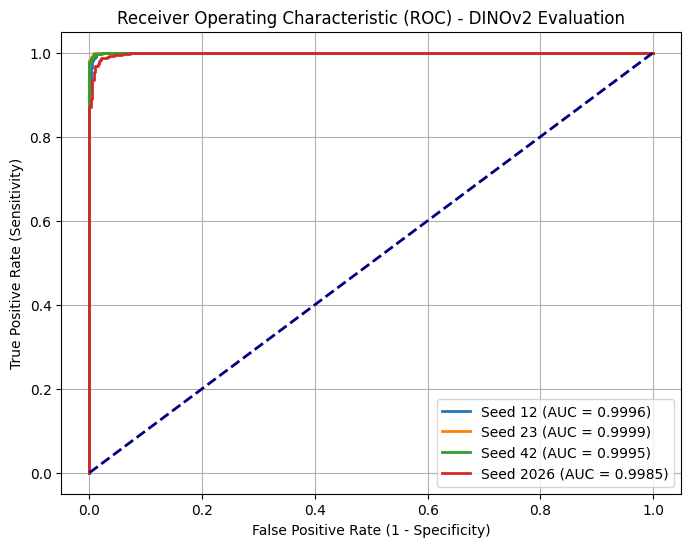

✅ ROC Curve plot saved to: /content/drive/MyDrive/Computer Vision Project/checkpoints/roc_auc_curve.png


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# Evaluate probabilities across seed checkpoints
for seed in SEEDS:
    # Load model architecture & saved weights
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)
    checkpoint_path = os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth")
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    # Get raw sigmoid probabilities
    y_true_all, y_probs_all = [], []

    with torch.no_grad():
        for images, labels in val_brats_loader:
            outputs = model(images.to(device))
            y_probs_all.extend(outputs.cpu().numpy())
            y_true_all.extend(labels.numpy())

        for images, labels in val_healthy_loader:
            outputs = model(images.to(device))
            y_probs_all.extend(outputs.cpu().numpy())
            y_true_all.extend(labels.numpy())

    # Compute ROC Curve & AUC score
    fpr, tpr, _ = roc_curve(y_true_all, y_probs_all)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Seed {seed} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - DINOv2 Evaluation')
plt.legend(loc="lower right")
plt.grid(True)

# Save ROC plot to Google Drive
plot_save_path = os.path.join(SAVE_WEIGHTS_DIR, 'roc_auc_curve.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ROC Curve plot saved to: {plot_save_path}")